In [1]:
!pip install tensorflow matplotlib numpy

In [2]:
import os

print("Files here:", os.listdir())
print("Inside dataset:", os.listdir("dataset"))
print("Inside train:", os.listdir("dataset/train"))
print("Inside test:", os.listdir("dataset/test"))

Files here: ['.ipynb_checkpoints', 'app-Copy1final.py', 'app.py', 'dataset', 'pneumonia_model.h5', 'pneumonia_model.keras', 'pneumonia_trainig-backup .ipynb', 'pneumonia_trainigorginal.ipynb']
Inside dataset: ['test', 'train']
Inside train: ['NORMAL', 'PNEUMONIA']
Inside test: ['NORMAL', 'PNEUMONIA']


In [3]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import numpy as np

In [4]:
train_path = "dataset/train"
test_path = "dataset/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=25,
    zoom_range=0.25,
    shear_range=0.2,
    horizontal_flip=True,
    width_shift_range=0.2,
    height_shift_range=0.2,
    validation_split=0.2   # 🔥 NEW
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = train_datagen.flow_from_directory(
    train_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

test_data = test_datagen.flow_from_directory(
    test_path,
    target_size=(150,150),
    batch_size=32,
    class_mode='binary'
)

Found 4173 images belonging to 2 classes.
Found 1043 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


In [5]:
model = models.Sequential()

model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(150,150,3)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(128, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))  # 🔥 prevents overfitting

model.add(layers.Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

C:\Users\athul\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,735,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,828,481 (18.42 MB)

 Trainable params: 4,828,481 (18.42 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    train_data,
    epochs=8,   # 🔥 increased epochs
    validation_data=val_data
)

Epoch 1/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 350s 3s/step - accuracy: 0.7407 - loss: 0.5415 - val_accuracy: 0.7440 - val_loss: 0.4890
Epoch 2/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 347s 3s/step - accuracy: 0.7498 - loss: 0.4334 - val_accuracy: 0.7651 - val_loss: 0.5111
Epoch 3/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 373s 3s/step - accuracy: 0.8081 - loss: 0.3776 - val_accuracy: 0.8351 - val_loss: 0.3670
Epoch 4/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 306s 2s/step - accuracy: 0.8486 - loss: 0.3318 - val_accuracy: 0.8504 - val_loss: 0.3207
Epoch 5/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.8675 - loss: 0.3061 - val_accuracy: 0.8706 - val_loss: 0.2810
Epoch 6/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 293s 2s/step - accuracy: 0.8723 - loss: 0.2976 - val_accuracy: 0.8428 - val_loss: 0.3164
Epoch 7/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 320s 2s/step - accuracy: 0.8780 - loss: 0.2787 - val_accuracy: 0.8782 - val_loss: 0.2661
Epoch 8/8
131/131 ━━━━━━━━━━━━━━━━━━━━ 289s 2s/step - accuracy: 0.8833 - loss: 0.2712 - val_accuracy: 0.

In [7]:
print("Final Training Accuracy:", history.history['accuracy'][-1])
print("Final Validation Accuracy:", history.history['val_accuracy'][-1])

Final Training Accuracy: 0.8832973837852478
Final Validation Accuracy: 0.8878235816955566


In [8]:
model.save("pneumonia_model.keras")

In [9]:
from tensorflow.keras.preprocessing import image

img_path = "dataset/test/PNEUMONIA/person101_bacteria_486.jpeg"

img = image.load_img(img_path, target_size=(150,150))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)

if prediction[0][0] > 0.5:
    confidence = prediction[0][0] * 100
    print(f"Predicted: PNEUMONIA ({confidence:.2f}%)")

    print("\nPrecautions:")
    print("- Consult a doctor")
    print("- Take proper rest")
    print("- Stay hydrated")

else:
    confidence = (1 - prediction[0][0]) * 100
    print(f"Predicted: NORMAL ({confidence:.2f}%)")

    print("\nHealthy Tips:")
    print("- Exercise regularly")
    print("- Eat healthy food")
    print("- Avoid smoking")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
Predicted: PNEUMONIA (100.00%)

Precautions:
- Consult a doctor
- Take proper rest
- Stay hydrated


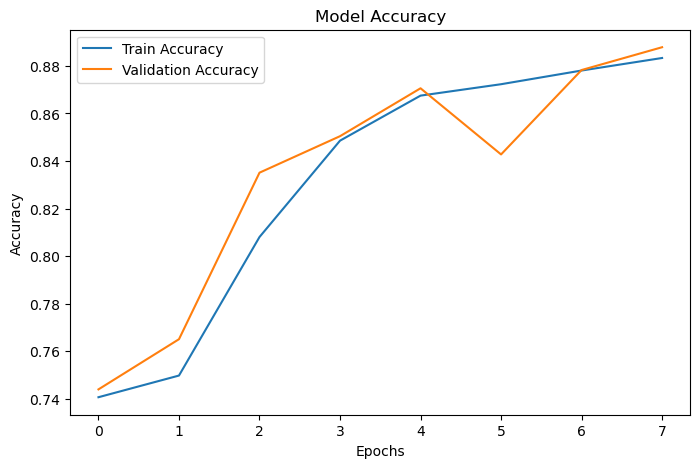

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

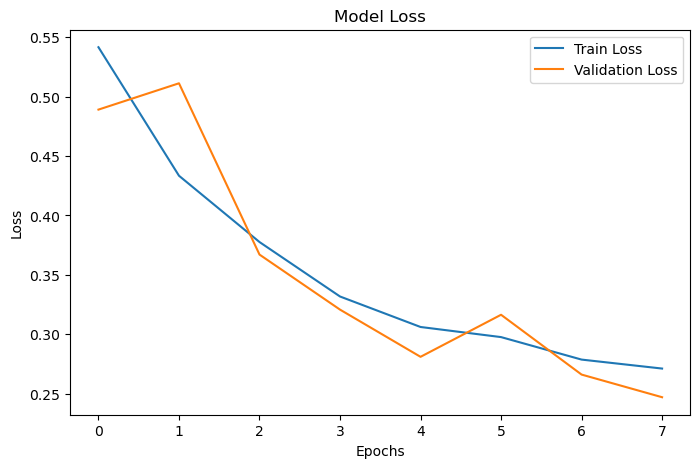

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()